In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [2]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality           gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.065177  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.035232  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.029855  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.094906  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.026733  6.060642   

   urban_pop  life_exp  fertility  labor_rate  internet  broadband  \
0     47.908    68.660      2.992      37.841  1.496850        NaN   
1     18.586    61.465      3.794      77.834  0.047023        NaN   
2     42.958    66.323      4.071         NaN  1.785230        NaN   
3     56.098    69.665      1.898      65.381  0.668594        NaN   
4     51.814    73.104      2.345      58.147  3.115780        NaN   

   health_exp  smoking  
0   10.588044     15.9  
1    8.591736     23.5  
2   11.406236     53.9  
3   

In [3]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

171


In [4]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [5]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czech', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [6]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    3312
1     792
Name: count, dtype: int64


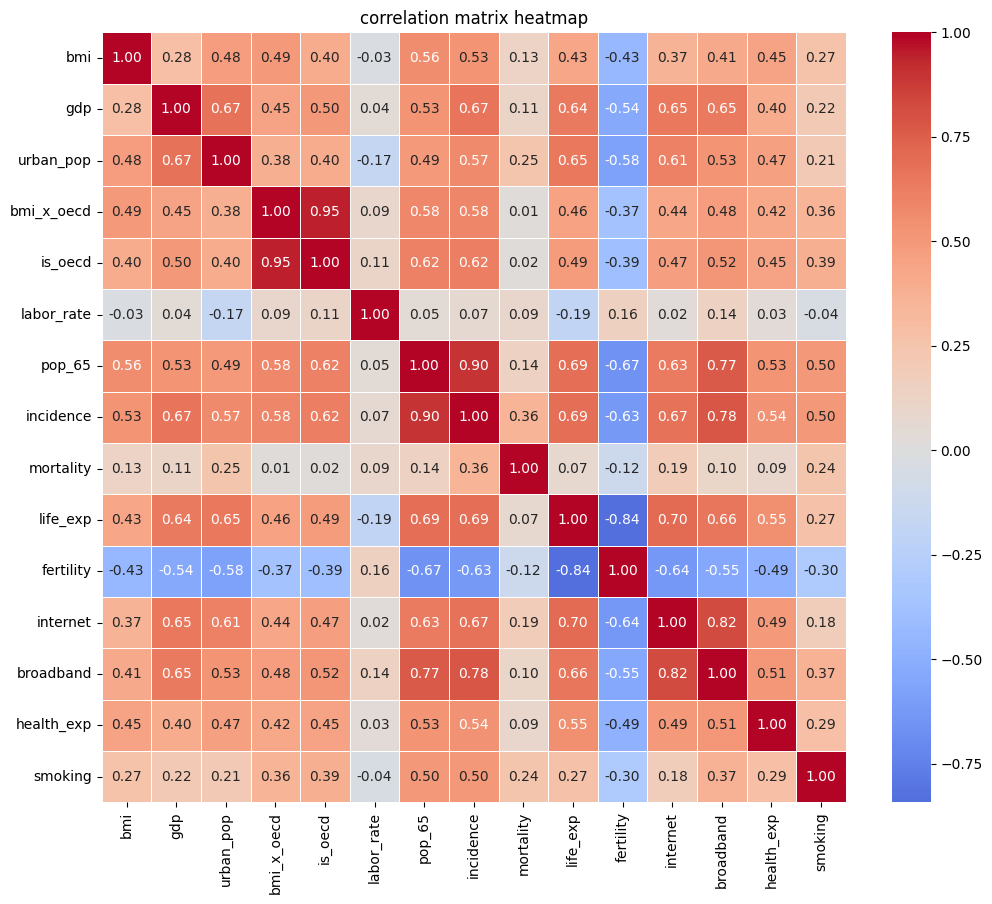

In [7]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility','internet','broadband','health_exp','smoking']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [8]:
final_df['is_oecd']= final_df['country'].str.lower().str.strip().isin(oecd_countries).astype(int)
print(final_df['is_oecd'].value_counts())

is_oecd
0    3312
1     792
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [9]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2762
1    1342
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [10]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
1    2094
0    2010
Name: count, dtype: int64


In [11]:
comparison_inc= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_inc)

dm_high_life_exp
0    24.636303
1    90.325215
Name: incidence, dtype: float64


In [12]:
comparison_incid= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_incid)

dm_high_life_exp
0    24.636303
1    90.325215
Name: incidence, dtype: float64


In [13]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year              country  is_oecd  dm_high_aging_society  \
0   2000                 fiji        0                      0   
1   2000             cambodia        0                      0   
2   2000             kiribati        0                      0   
3   2000           kazakhstan        0                      0   
4   2000              jamaica        0                      0   
..   ...                  ...      ...                    ...   
95  2000                spain        1                      1   
96  2000               cyprus        0                      0   
97  2000  antigua and barbuda        0                      0   
98  2001                malta        0                      1   
99  2001               canada        1                      1   

    dm_high_life_exp  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
..               ...  
95                 1  
96                 1  
97          

# interaction of is_oecd variable and gdp

In [14]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [15]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [16]:
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society', 'dm_high_life_exp']].sample(20).round(2))

                   country        gdp  is_oecd  log_gdp_is_oecd  \
1102                 benin    2729.14        0             0.00   
2120                  oman   40854.49        0             0.00   
2533                zambia    3585.58        0             0.00   
570                 guinea    2473.23        0             0.00   
821                morocco    5996.39        0             0.00   
3478            luxembourg  132573.99        1            11.79   
325               kiribati    2341.70        0             0.00   
1583              paraguay   12738.58        0             0.00   
1877           netherlands   62318.14        1            11.04   
4071  syrian arab republic    4189.84        0             0.00   
33               sri lanka    6230.03        0             0.00   
2442               belarus   24846.83        0             0.00   
301                  malta   31179.30        0             0.00   
2983               burundi     880.99        0             0.0

In [17]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                   country  dm_high_aging_society  dm_high_life_exp
4004  2021                  zimbabwe                      0                 0
4005  2021  central african republic                      0                 0
4006  2021                   bahrain                      0                 1
4007  2021                madagascar                      0                 0
4008  2021                    malawi                      0                 0
...    ...                       ...                    ...               ...
4099  2023                    monaco                      1                 1
4100  2023                  dominica                      1                 0
4101  2023                 argentina                      1                 1
4102  2023        dominican republic                      0                 1
4103  2023                     nauru                      0                 0

[100 rows x 4 columns]
number of countries with high life_expec

# delet rows with missing value(NA) in all variables 

In [18]:
# گزارش درصدی برای بررسی نهایی قبل از رگرسیون
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print("--- 📊 Percentage of Missing Values ---")
print(missing_report[missing_report > 0]) # فقط آن‌هایی که خالی دارند را نشان بده

--- 📊 Percentage of Missing Values ---
gdp            3.265107
labor_rate     8.260234
internet       4.556530
broadband     16.301170
health_exp     6.822612
smoking       15.204678
log_gdp        3.265107
dtype: float64


In [19]:
clean_df= final_df.dropna(subset=['incidence','mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'broadband', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
internet                 0
broadband                0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding Urban Population and log_gdp

In [20]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['incidence'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0108
Estimator:                   PanelOLS   R-squared (Between):              0.1839
No. Observations:                2678   R-squared (Within):               0.1271
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1768
Time:                        14:20:58   Log-likelihood                   -8496.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      13.734
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(2,2516)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             13.734
                            

# Step 2: Adding Pop_65:

In [21]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['incidence'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0370
Estimator:                   PanelOLS   R-squared (Between):              0.7169
No. Observations:                2678   R-squared (Within):               0.2932
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.7112
Time:                        14:20:58   Log-likelihood                   -8460.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      32.247
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(3,2515)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             32.247
                            

# Step 3: Adding Labor Rate:

In [22]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['incidence'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0371
Estimator:                   PanelOLS   R-squared (Between):              0.4102
No. Observations:                2678   R-squared (Within):               0.2910
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.3990
Time:                        14:20:59   Log-likelihood                   -8460.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      24.238
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(4,2514)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             24.238
                            

# Step 4: Adding BMI:

In [23]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['incidence'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0670
Estimator:                   PanelOLS   R-squared (Between):              0.4555
No. Observations:                2678   R-squared (Within):               0.2689
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.4400
Time:                        14:20:59   Log-likelihood                   -8417.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      36.109
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(5,2513)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             36.109
                            

# Step 5: Adding is_oecd as Dummy Variable:

In [24]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['incidence'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0697
Estimator:                   PanelOLS   R-squared (Between):             -0.2998
No. Observations:                2678   R-squared (Within):               0.2660
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.3202
Time:                        14:20:59   Log-likelihood                   -8414.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      31.368
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(6,2512)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             31.368
                            

# Step 6: Adding High aging society as Dummy Variable:

In [25]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['incidence'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0725
Estimator:                   PanelOLS   R-squared (Between):             -0.2878
No. Observations:                2678   R-squared (Within):               0.2744
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.3087
Time:                        14:20:59   Log-likelihood                   -8410.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      28.053
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(7,2511)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             28.053
                            

# Step 7: Adding High life exp as Dummy Variable:

In [26]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_7_fe = PanelOLS(df_step['incidence'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0740
Estimator:                   PanelOLS   R-squared (Between):             -0.1927
No. Observations:                2678   R-squared (Within):               0.2816
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.2137
Time:                        14:20:59   Log-likelihood                   -8407.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      25.071
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(8,2510)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             25.071
                            

# create labor_rate * is_oecd variable:

In [27]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [28]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi',
                                     'log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['incidence'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0878
Estimator:                   PanelOLS   R-squared (Between):              0.1233
No. Observations:                2678   R-squared (Within):               0.2550
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1062
Time:                        14:20:59   Log-likelihood                   -8387.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      26.832
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(9,2509)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             26.832
                            

# Step 9: Adding internet:

In [29]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['incidence'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1457
Estimator:                   PanelOLS   R-squared (Between):              0.2082
No. Observations:                2678   R-squared (Within):               0.5239
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1940
Time:                        14:20:59   Log-likelihood                   -8300.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      42.768
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(10,2508)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             42.768
                            

# Step  10: Adding broadband:

In [30]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband']])
model_10_fe = PanelOLS(df_step['incidence'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1668
Estimator:                   PanelOLS   R-squared (Between):              0.3241
No. Observations:                2678   R-squared (Within):               0.5220
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.3130
Time:                        14:20:59   Log-likelihood                   -8266.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      45.637
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(11,2507)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             45.637
                            

# Step  11: Adding smoking:

In [31]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking']])
model_11_fe = PanelOLS(df_step['incidence'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1992
Estimator:                   PanelOLS   R-squared (Between):              0.6339
No. Observations:                2678   R-squared (Within):               0.4371
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6209
Time:                        14:20:59   Log-likelihood                   -8213.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      51.947
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(12,2506)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             51.947
                            

# step 12: adding health_exp:

In [32]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp']])
model_12_fe = PanelOLS(df_step['incidence'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.2033
Estimator:                   PanelOLS   R-squared (Between):              0.6409
No. Observations:                2678   R-squared (Within):               0.4345
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6276
Time:                        14:21:00   Log-likelihood                   -8206.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      49.163
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(13,2505)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             49.163
                            

# Comparing results of all Fixed Effect models:

In [33]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe })

print(Compare_results_fixed_Effect)

                                                                                               Model Comparison                                                                                              
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 

In [34]:
# لیست تمام متغیرهایی که در کل مدل‌هایت (چه بروز، چه مرگ) استفاده شده
all_variables = ['incidence', 'mortality', 'gdp', 'bmi', 'smoking', 'broadband', 'health_exp', 'urban_pop', 'pop_65', 'labor_rate', 'internet', 'life_exp']

# تمیزکاری نهایی بر اساس کل لیست
clean_data = final_df.dropna(subset=all_variables)

print("تعداد ردیف‌های کاملاً مشترک:", len(clean_data))

تعداد ردیف‌های کاملاً مشترک: 2678
